In [ ]:
%cd ..

/home/ricka/Git/GitHub/RickArko/kaggle/comp/kcom-predicting-stellar-class


# Exploratory Data Analysis — Predicting Stellar Class (S6E6)

**Competition:** https://www.kaggle.com/competitions/playground-series-s6e6  
**Goal:** Classify astronomical objects as GALAXY, STAR, or QSO  
**Metric:** Balanced Accuracy

### Contents
1. Load data
2. Dataset overview
3. Target distribution
4. Feature distributions
5. Correlation analysis
6. Class-conditional distributions
7. Key takeaways

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline
from stellar.data import load_data

train, test = load_data('data/')
print('Train:', train.shape)
print('Test: ', test.shape)

Train shape: (577347, 12), Test shape: (247435, 11)
Train: (577347, 12)
Test:  (247435, 11)


## 1. Dataset Overview

In [ ]:
train.head()

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


In [ ]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 577347 non-null  int64  
 1   alpha              577347 non-null  float64
 2   delta              577347 non-null  float64
 3   u                  577347 non-null  float64
 4   g                  577347 non-null  float64
 5   r                  577347 non-null  float64
 6   i                  577347 non-null  float64
 7   z                  577347 non-null  float64
 8   redshift           577347 non-null  float64
 9   spectral_type      577347 non-null  str    
 10  galaxy_population  577347 non-null  str    
 11  class              577347 non-null  str    
dtypes: float64(8), int64(1), str(3)
memory usage: 52.9 MB


In [ ]:
train.describe()

,id,alpha,delta,u,g,r,i,z,redshift
count,577347.00000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000
mean,288673.00000,181.616673,21.834654,22.441926,21.007273,19.962811,19.378911,19.041136,0.723135
std,166665.86727,96.242941,18.933570,2.018135,1.795426,1.648964,1.580059,1.584365,0.810070
min,0.00000,0.011684,-17.966988,-0.139225,13.535483,12.579407,11.962781,11.682803,-0.009970
25%,144336.50000,132.161499,2.474097,20.977090,19.865005,18.820671,18.306820,17.973192,0.181052
50%,288673.00000,188.681465,21.484412,22.570222,21.467820,20.431153,19.631642,19.188598,0.497525
75%,433009.50000,231.829693,36.988310,23.869103,22.292715,21.164096,20.608191,20.162111,0.881390
max,577346.00000,359.999810,79.158322,28.253263,27.620208,25.254499,27.910853,26.826867,7.010780


In [ ]:
# Missing values
missing = train.isnull().sum()
print('Missing values in train:')
print(missing[missing > 0] if missing.sum() > 0 else 'None')

Missing values in train:
None


## 2. Target Distribution

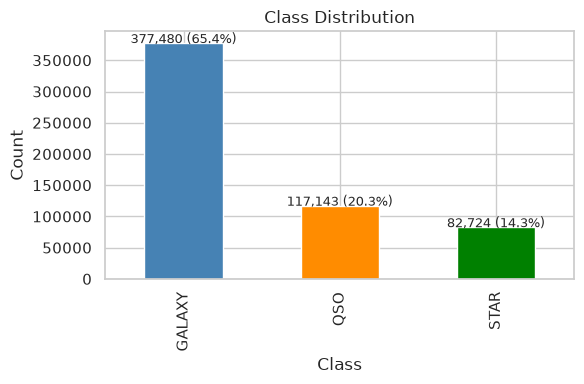

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = train['class'].value_counts()
counts.plot(kind='bar', ax=ax, color=['steelblue', 'darkorange', 'green'])
ax.set_title('Class Distribution')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
for i, v in enumerate(counts):
    ax.text(i, v + 50, f'{v:,} ({v/len(train)*100:.1f}%)', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 3. Feature Distributions

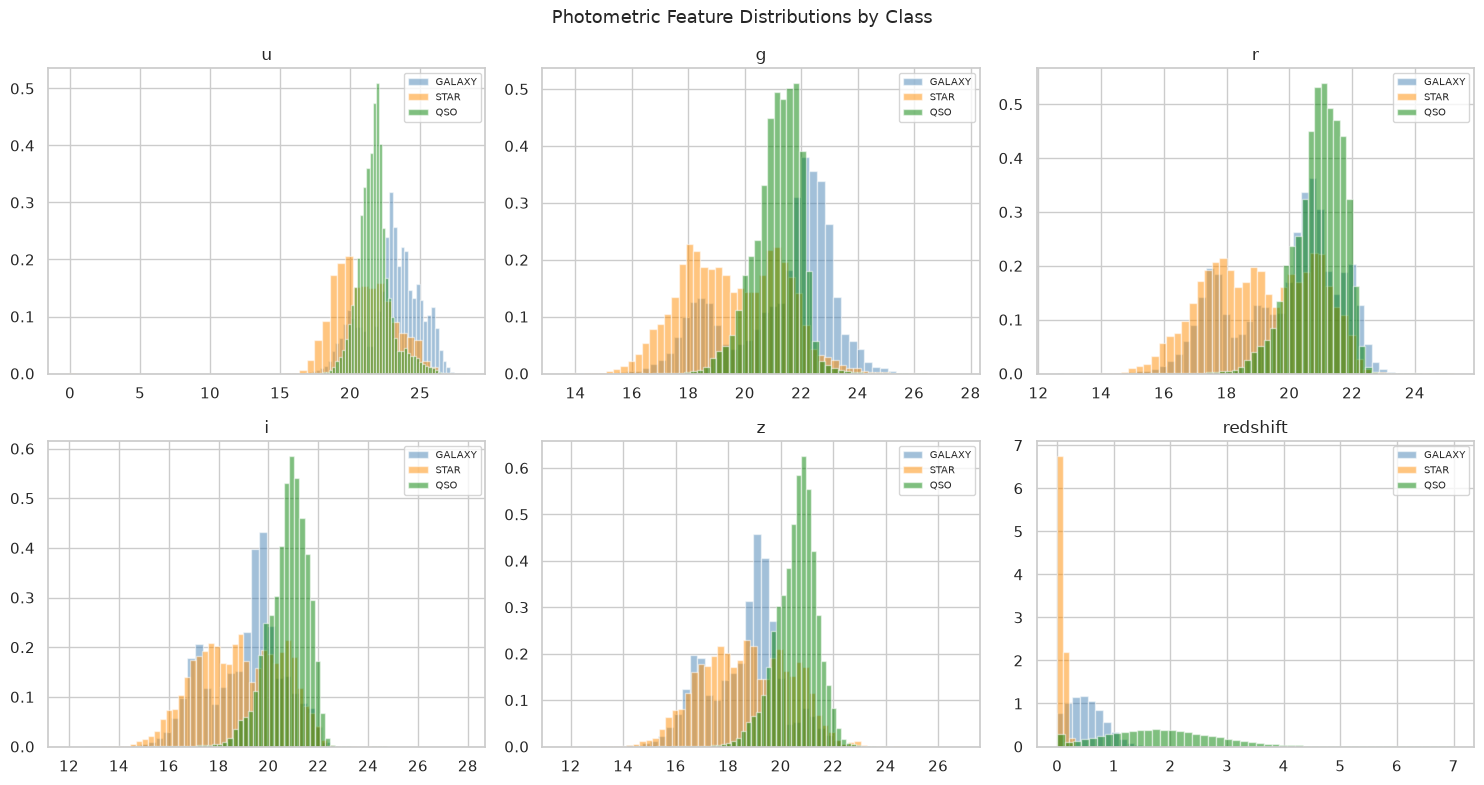

In [ ]:
photometric = ['u', 'g', 'r', 'i', 'z', 'redshift']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), photometric):
    for cls, color in zip(['GALAXY', 'STAR', 'QSO'], ['steelblue', 'darkorange', 'green']):
        data = train.loc[train['class'] == cls, col].dropna()
        ax.hist(data, bins=50, alpha=0.5, label=cls, color=color, density=True)
    ax.set_title(col)
    ax.legend(fontsize=7)
plt.suptitle('Photometric Feature Distributions by Class', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Correlation Analysis

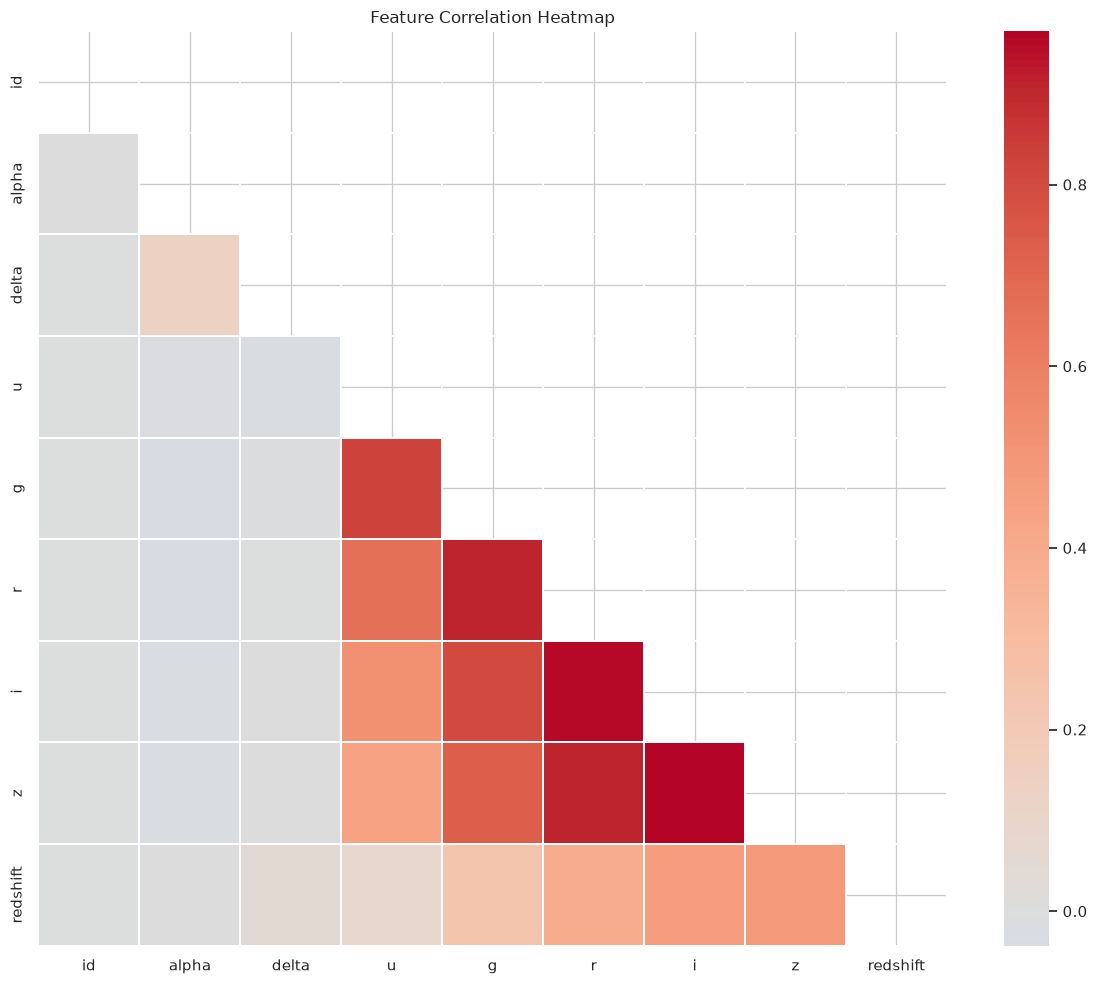

In [ ]:
numeric_cols = train.select_dtypes(include='number').columns.tolist()
corr = train[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.3)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## 5. Redshift vs Photometric Bands

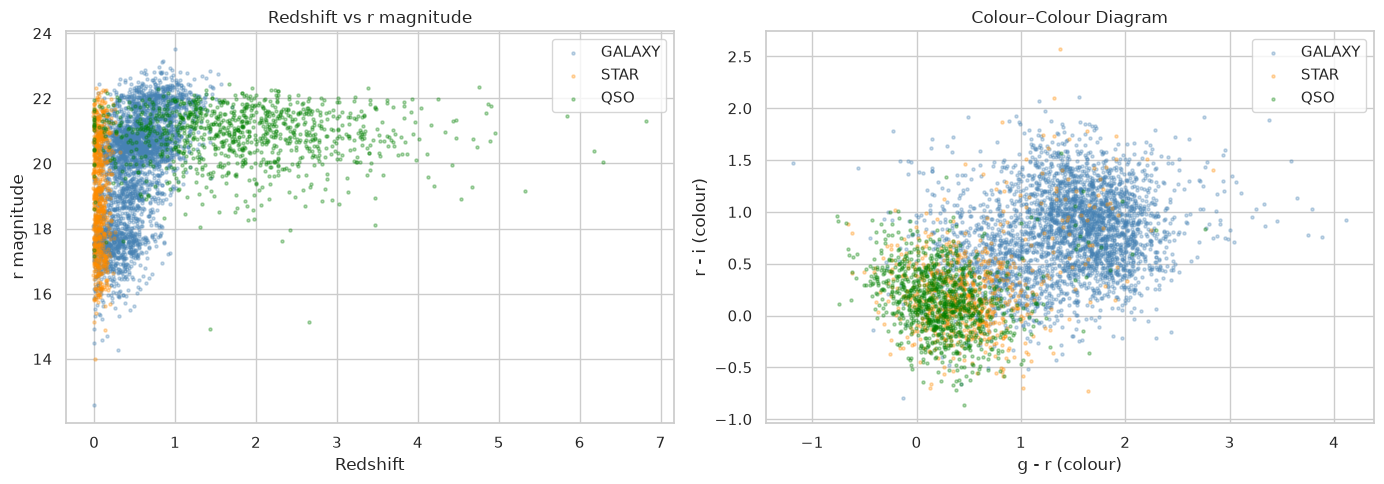

In [ ]:
sample = train.sample(min(5000, len(train)), random_state=42)
palette = {'GALAXY': 'steelblue', 'STAR': 'darkorange', 'QSO': 'green'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cls, color in palette.items():
    sub = sample[sample['class'] == cls]
    axes[0].scatter(sub['redshift'], sub['r'], alpha=0.3, s=5, color=color, label=cls)
    axes[1].scatter(sub['g'] - sub['r'], sub['r'] - sub['i'], alpha=0.3, s=5, color=color, label=cls)

axes[0].set_xlabel('Redshift')
axes[0].set_ylabel('r magnitude')
axes[0].set_title('Redshift vs r magnitude')
axes[0].legend()

axes[1].set_xlabel('g - r (colour)')
axes[1].set_ylabel('r - i (colour)')
axes[1].set_title('Colour–Colour Diagram')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Key Takeaways

- **Redshift** is the single most discriminating feature: QSOs cluster at high redshifts, stars near zero.
- **Photometric colours** (band differences) are more informative than raw magnitudes.
- The dataset appears relatively balanced; balanced accuracy is still the evaluation metric so all classes matter.
- `alpha` / `delta` (sky coordinates) show little class separation and can be dropped.
- ID columns (`obj_ID`, `run_ID`, etc.) carry no signal and should be dropped.